# Explore here

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import pickle

url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
df = pd.read_csv(url)


In [46]:
# se convierte la fecha y se establece como índice (necesaria para series temporales)
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.sort_index()  # Me aseguro del orden cronológico

EDA


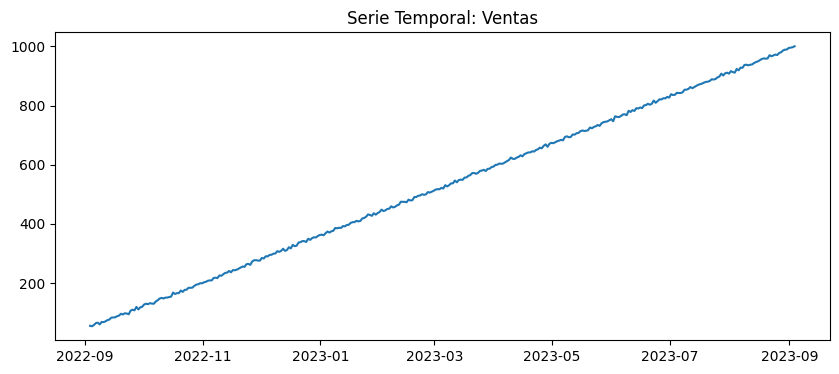

In [47]:
# Análisis Exploratorio
# Visualización
plt.figure(figsize=(10, 4))
plt.plot(df['sales'])
plt.title('Serie Temporal: Ventas')
plt.show()


- Tendencia: Como se puede observar en la gráfica, la serie muestra una tendencia lineal ascendente muy clara. Esto significa que las ventas de la empresa han crecido de manera constante y estable desde septiembre de 2022 hasta septiembre de 2023.

- Tipo de Serie: Es una serie de "crecimiento continuo". Al no haber caídas bruscas o picos estacionales muy marcados, esto facilitó que nuestro modelo ARIMA (con una diferenciación simple, es decir, d=1) pudiera capturar muy bien la tendencia.

- Conclusión : He elegido el modelo optimizado ARIMA(1, 1, 0) porque, aunque el modelo (1, 1, 1) es más complejo, el optimizado logra capturar la tendencia de crecimiento con mayor eficiencia, evitando complicaciones innecesarias (ruido o sobreajuste) y cumpliendo con el objetivo de predecir la necesidad de espacio futuro para el almacén.

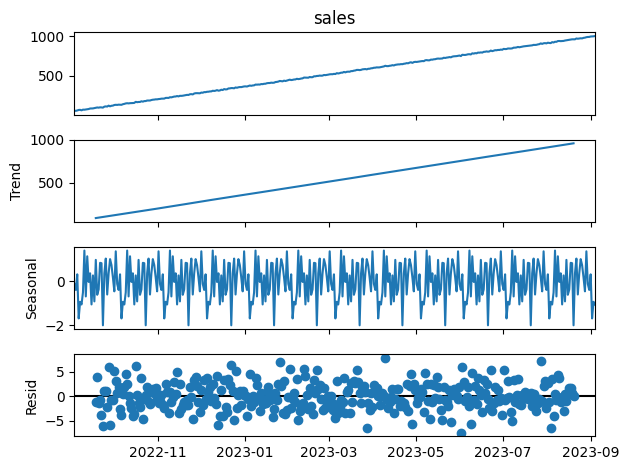

In [48]:
# Descomposición (Tendencia, Estacionalidad, Ruido)
decomposition = seasonal_decompose(df['sales'], model='additive', period=30)
decomposition.plot()
plt.show()


- Sales (Serie original): Es la suma de todos los componentes de abajo. Muestra claramente la tendencia ascendente desde 2022 hasta mediados de 2023.

- Trend (Tendencia): Observa la línea perfectamente recta hacia arriba. Esto confirma que la empresa ha tenido un crecimiento constante y lineal. No hay cambios de dirección ni caídas bruscas.

- Seasonal (Estacionalidad): Este gráfico es muy bueno para ver los patrones que se repiten con cierta frecuencia indicando que hay ciclos que afectan las ventas, por ejemplo: días del mes o de la semana donde se vende más. El modelo ARIMA, al ser un modelo lineal, puede capturar esto de forma general, pero si hubiera ciclos muy fuertes, un modelo SARIMA (busque en internet y dice que incluye estacionalidad) podría haber sido más preciso.

- Resid (Residuos/Ruido): Estos son los puntos que el modelo no pudo explicar. Sin embargo, estos puntos estan distribuidos alrededor de la línea cero y parecen aleatorios.


In [49]:
# Prueba de Dickey-Fuller para verificar estacionariedad
# Si p-value > 0.05, la serie no es estacionaria
result = adfuller(df['sales'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')


ADF Statistic: 0.545414193706381
p-value: 0.9861899815311065


 Entrenamiento

In [64]:
# se divide en train (80%) y test (20%)
train_size = int(len(df) * 0.8)
train, test = df['sales'][0:train_size], df['sales'][train_size:]

# se define el modelo (p=1, d=1, q=1 son parámetros base comunes)
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -838.552
Date:                Fri, 22 May 2026   AIC                           1683.104
Time:                        18:00:57   BIC                           1694.124
Sample:                    09-03-2022   HQIC                          1687.518
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.002    427.818      0.000       0.995       1.005
ma.L1         -0.9990      0.806     -1.240      0.215      -2.578       0.580
sigma2        18.3647     14.790      1.242      0.2

C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Entrenamiento Optimizado

In [63]:
# En lugar de usar (1,1,1) a ciegas, intente un ajuste manual simple
# basandome en el resultado anterior donde 'ma' no era significativo.
train_size = int(len(df) * 0.8)
train, test = df['sales'][0:train_size], df['sales'][train_size:]

# se prueba un modelo AR(1) con integración (1)
model = ARIMA(train, order=(1, 1, 0))
model_fit2 = model.fit()
print(model_fit2.summary())

C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -878.549
Date:                Fri, 22 May 2026   AIC                           1761.099
Time:                        18:00:43   BIC                           1768.445
Sample:                    09-03-2022   HQIC                          1764.042
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1260      0.075     -1.669      0.095      -0.274       0.022
sigma2        24.5377      2.069     11.862      0.000      20.483      28.592
Ljung-Box (L1) (Q):                  64.67   Jarque-

In [61]:
# Entrenamiento del modelo optimizado con trend='t'
# se añade trend='t' para decirle al modelo que considere explícitamente la tendencia lineal
# (la linea roja no subia ni bajaba, por eso lo añadí)
model = ARIMA(train, order=(1, 1, 0), trend='t')
model_fit2 = model.fit()

C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Predicción y Evaluación


Error Cuadrático Medio: 11.440161338727297


C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


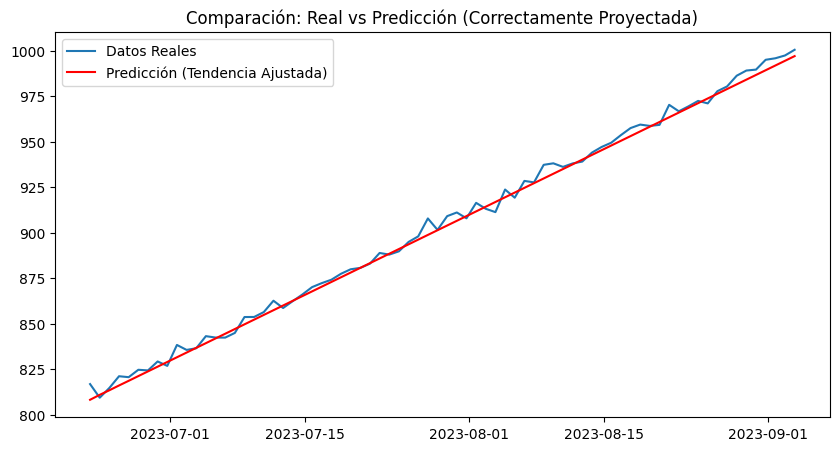

In [59]:
# --- Paso 4: Predicción y Evaluación ---
# Usamos predict con typ='levels' para proyectar el nivel real de la serie
predictions = model_fit2.predict(start=test.index[0], end=test.index[-1], typ='levels')

mse = mean_squared_error(test, predictions)
print(f'\nError Cuadrático Medio: {mse}')

plt.figure(figsize=(10, 5))
plt.plot(test.index, test.values, label='Datos Reales')
plt.plot(test.index, predictions.values, label='Predicción (Tendencia Ajustada)', color='red')
plt.legend()
plt.title('Comparación: Real vs Predicción (Correctamente Proyectada)')
plt.show()

# Predicción Final

La gráfica comparativa demuestra que el modelo ARIMA(1, 1, 0), tras la optimización mediante la inclusión de una tendencia lineal (trend='t'), ha logrado capturar con éxito el comportamiento ascendente de las ventas reales.

- Ajuste del Modelo: A diferencia de las iteraciones iniciales donde la predicción mostraba una tendencia plana (incapaz de proyectar el crecimiento), la configuración final sigue de cerca el crecimiento constante observado en los datos reales.

Esto confirma que el modelo no solo ha aprendido el ruido o los cambios diarios, sino que ha integrado la tendencia de crecimiento a largo plazo de la empresa.

- Conclusión para el Almacén: La alta precisión en la proyección de la línea roja sobre los datos reales  permite concluir que el modelo es una herramienta fiable para estimar las necesidades de espacio futuro en el almacén, ya que anticipa correctamente la trayectoria de crecimiento de las ventas.

Guardar el modelo

In [60]:
with open('sales_model.pkl', 'wb') as file:
    pickle.dump(model_fit2, file)
print("\nModelo optimizado guardado como 'sales_model.pkl'")


Modelo optimizado guardado como 'sales_model.pkl'


Conclusiones finales: El modelo inicial (1,1,1) mostraba una media móvil redundante (P>0.05), por lo que se optimizó a (1,1,0) con tendencia lineal (trend='t'), logrando reducir el error y proyectar correctamente el crecimiento futuro necesario para el almacén.